In [1]:
import os, shutil

import requests
from extractDataSrc.Lasco import Lasco
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy

from PIL import Image
import json


from skimage.measure import label, regionprops
import math
from matplotlib.patches import Ellipse

from skimage import exposure
from skimage.filters import meijering, frangi, sato
from skimage.morphology import disk, closing, footprint_rectangle

from sklearn.cluster import DBSCAN
from sklearn.linear_model import RANSACRegressor

from scipy.interpolate import interp1d

import warnings

In [48]:
dir_path = './data_processed/testing_images_c3/event1/'

In [49]:
# ─────────────────────────────────────────────
#  Constants (physical, not path-dependent)
# ─────────────────────────────────────────────
ARCSEC_TO_KM = 725.0    # Approximate conversion at 1 AU
V_MIN_KM_S   = 250.0    # Minimum plausible CME speed
V_MAX_KM_S   = 2000.0   # Maximum plausible CME speed


# ─────────────────────────────────────────────
#  Helpers
# ─────────────────────────────────────────────

def get_date_range(date_str):
    dt = datetime.strptime(date_str, '%Y-%m-%d %H:%M:%S')
    start = (dt - timedelta(hours=2)).replace(minute=0, second=0)
    end   = dt + timedelta(hours=12)
    return (
        start.strftime('%Y-%m-%d %H:%M:%S'),
        end.strftime('%Y-%m-%d %H:%M:%S')
    )


def load_images(dir_path):
    """Load all PNG images from dir_path.
    Expects a JSON metadata file called images_metadata.json in the same directory.
    """
    images = []
    for im in sorted(os.listdir(dir_path)):
        if im.endswith(".png"):
            img = Image.open(os.path.join(dir_path, im))
            images.append(np.array(img.convert('L')))

    # Use the first PNG as the reference image for shape
    first_png = next(f for f in sorted(os.listdir(dir_path)) if f.endswith('.png'))
    img = Image.open(os.path.join(dir_path, first_png))
    image_data = np.array(img.convert('L'))

    # Metadata lives alongside the images
    json_file = os.path.join(dir_path, 'images_metadata.json')
    with open(json_file, 'r') as f:
        metadata = json.load(f)

    return images, image_data, metadata


def download_metadata(time_str, save_dir):
    original_datetime = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S")
    date_str = original_datetime.strftime("%Y-%m-%dT%H:%M:%S.000Z")
    url = f"https://api.helioviewer.org/v2/getClosestImage/?date={date_str}&sourceId=5"

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        out_path = os.path.join(save_dir, "images_metadata.json")
        with open(out_path, 'w') as f:
            json.dump(data, f, indent=4)
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from Helioviewer API: {e}")
    except IOError as e:
        print(f"Error saving metadata: {e}")


# ─────────────────────────────────────────────
#  Core pipeline – everything that used to be
#  at module level is now inside this function.
# ─────────────────────────────────────────────


print(f"\n{'='*60}")
print(f"Running pipeline for: {dir_path}")
print(f"{'='*60}")

images, image_data, metadata = load_images(dir_path)

# ── Coordinate grids (depend on metadata, so computed per-run) ──
center_x = 512
center_y = 512

arcsec_per_pixel = metadata['scale']
rsun_pixels      = metadata['rsun']

height, width = image_data.shape
y_indices, x_indices = np.indices((height, width))

x_rel_pixels = x_indices - center_x
y_rel_pixels = center_y - y_indices

x_arcsec = x_rel_pixels * arcsec_per_pixel
y_arcsec = y_rel_pixels * arcsec_per_pixel

r_arcsec     = np.sqrt(x_arcsec**2 + y_arcsec**2)
theta_arcsec = np.arctan2(y_arcsec, x_arcsec)
theta_arcsec = np.mod(theta_arcsec, 2 * np.pi)

# ── Pylon angle detection ──
best_pylon_cover = None
phi = None
for pylon_angle in np.arange(0.01, 2, 0.01):
    pylon_mask = (
        (theta_arcsec < pylon_angle * np.pi) &
        (theta_arcsec > (pylon_angle - 7/100) * np.pi) &
        (r_arcsec > 4.7 * rsun_pixels * arcsec_per_pixel) &
        (r_arcsec < 512 * arcsec_per_pixel)
    )
    pylon       = image_data[pylon_mask]
    match_count = np.sum(pylon < 5)
    total_count = len(pylon)

    if best_pylon_cover is None or match_count / total_count > best_pylon_cover:
        best_pylon_cover = match_count / total_count
        phi = pylon_angle

# ── Inner functions that close over the per-run variables ──

def image_masking(img):
    mask = (
        (r_arcsec < 4.7 * rsun_pixels * arcsec_per_pixel) |
        (r_arcsec > 512 * arcsec_per_pixel) |
        ((theta_arcsec < phi * np.pi) & (theta_arcsec > (phi - 7/100) * np.pi))
    )
    img_masked = img.copy().astype(np.float32)
    img_masked[mask] = np.nan
    return img_masked

def prepare_image(image):
    h, w = image_data.shape
    yi, xi = np.indices((h, w))

    xr = (xi - center_x) * arcsec_per_pixel
    yr = (yi - center_y) * arcsec_per_pixel

    r_local     = np.sqrt(xr**2 + yr**2)
    theta_local = np.arctan2(yr, xr)

    mask = (
        (r_local < 4.7 * rsun_pixels * arcsec_per_pixel) |
        (r_local > 512 * arcsec_per_pixel) |
        ((theta_local < phi * np.pi) & (theta_local > (phi - 7/100) * np.pi))
    )
    img_masked = image.copy().astype(np.float32)
    img_masked[mask] = np.nan
    return img_masked, r_local, theta_local

def unroll_to_polar(img, r_arcsec_array, theta_arcsec_array,
                    num_radii=512, num_angles=360):
    R_max   = r_arcsec_array.max()
    R_new   = np.linspace(r_arcsec_array.min(), R_max, num_radii)
    Theta_new = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)
    R_grid, Theta_grid = np.meshgrid(R_new, Theta_new)

    occulter_cx = 512.0
    occulter_cy = 512.0
    indices_x = occulter_cx + R_grid * np.cos(Theta_grid) / arcsec_per_pixel
    indices_y = occulter_cy + R_grid * np.sin(Theta_grid) / arcsec_per_pixel

    coords = np.vstack([indices_y.ravel(), indices_x.ravel()])
    polar_map = scipy.ndimage.map_coordinates(
        input=img,
        coordinates=coords,
        order=1,
        cval=np.nan
    ).reshape(num_angles, num_radii)

    return polar_map.T

def create_jmap(diff_ims, center_angle, angular_width=5):
    j_map_slices = []
    half_width = angular_width // 2
    max_angle  = diff_ims[0].shape[1]
    start_angle_idx = max(0, center_angle - half_width)
    end_angle_idx   = min(max_angle, center_angle + half_width + 1)

    for polar_map in diff_ims[::-1]:
        swath = polar_map[:, start_angle_idx:end_angle_idx]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            clean_radial_slice = np.nanmean(swath, axis=1)
        j_map_slices.append(clean_radial_slice)

    return np.stack(j_map_slices, axis=0)

def resample_jmap_to_constant_cadence(j_map, cum_times_seconds, target_cadence_mins=12):
    """
    Interpolates a J-map with variable time gaps to a constant time step.
    
    j_map: The original 2D array [Time, Space]
    cum_times_seconds: 1D array of exact seconds for each row in j_map
    target_cadence_mins: The constant time step you want (e.g., 12 mins)
    """
    # The original time axis in minutes
    original_times_mins = cum_times_seconds / 60.0
    
    # Create a new, perfectly even time axis (every 12 minutes)
    max_time = original_times_mins[-1]
    new_times_mins = np.arange(0, max_time + target_cadence_mins, target_cadence_mins)
    
    # Interpolate the J-map along the time axis (axis 0)
    # interp1d creates a mathematical function from your data
    interpolator = interp1d(original_times_mins, j_map, axis=0, kind='linear', fill_value="extrapolate")
    
    # Generate the new J-map using the perfectly even time steps
    resampled_jmap = interpolator(new_times_mins)
    
    return resampled_jmap



Running pipeline for: ./data_processed/testing_images_c3/event1/


In [50]:
prepared_images      = []
prepared_r_arcsecs   = []
prepared_theta_arcsecs = []

for image in images:
    im, r, t = prepare_image(image)
    prepared_images.append(im)
    prepared_r_arcsecs.append(r)
    prepared_theta_arcsecs.append(t)

# ── Cumulative times ──
files = sorted(f for f in os.listdir(dir_path) if f.endswith('.png'))
time_strings = []
for im in files:
    parts         = im.split('_')
    full_time_str = f"{parts[0]}_{parts[1]}"
    time_strings.append(full_time_str)

times    = pd.to_datetime(time_strings, format='%Y%m%d_%H%M')
t0       = times[0]
cum_times = np.array([(t - t0).total_seconds() for t in times])

# ── Polar transform + running difference ──
polar_maps = [
    unroll_to_polar(img, r, t)
    for img, r, t in zip(prepared_images, prepared_r_arcsecs, prepared_theta_arcsecs)
]

running_difference = [
    np.clip(polar_maps[i] - polar_maps[i-1], 0, 255)
    for i in range(1, len(polar_maps))
]

In [51]:
total_duration_sec = cum_times[-1] - cum_times[0]
expected_intervals = total_duration_sec / 720
actual_intervals = len(cum_times) - 1
cadence_score = actual_intervals / expected_intervals
cadence_score

np.float64(0.2916666666666667)

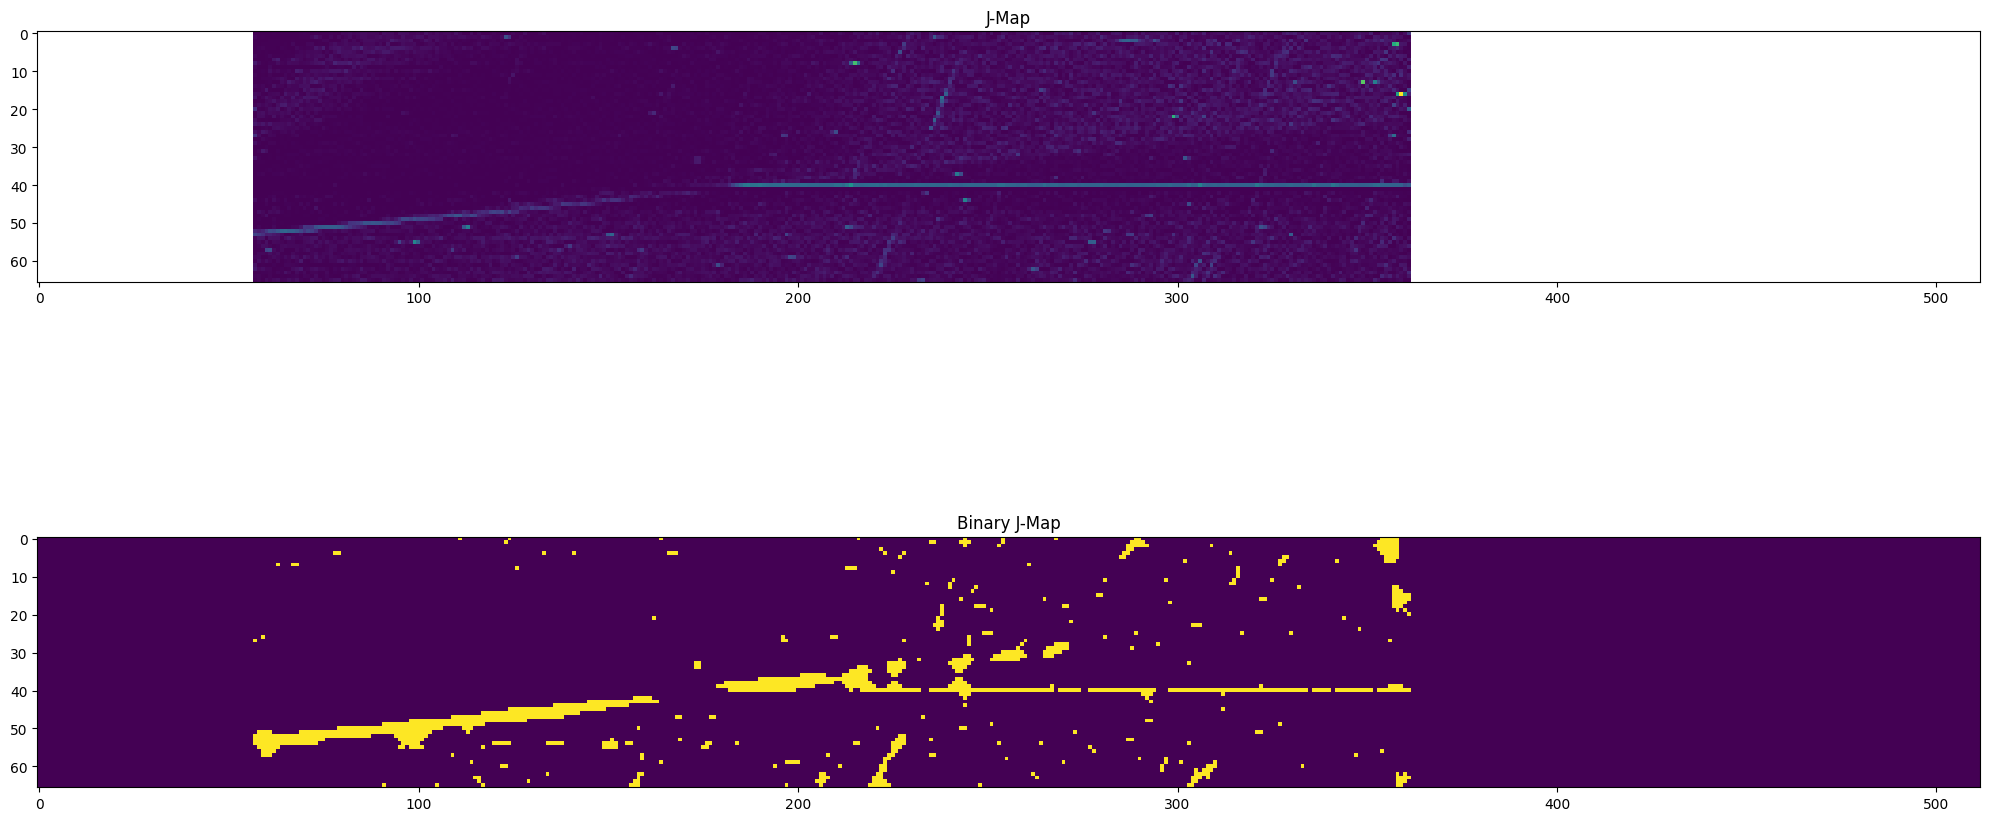

In [42]:
j_map = create_jmap(running_difference, 10)

j_map_clean = np.nan_to_num(j_map, nan=0.0, posinf=0.0, neginf=0.0)
p1, p99 = np.percentile(j_map_clean, (1, 99))
j_map_clipped = np.clip(j_map_clean, p1, p99)
j_map_norm = (j_map_clipped - j_map_clipped.min()) / (j_map_clipped.max() - j_map_clipped.min())
j_map_eq = exposure.equalize_adapthist(j_map_norm, clip_limit=0.03)

j_map_blobs = meijering(j_map_eq, sigmas=range(1, 4), black_ridges=False)
threshold = np.percentile(j_map_blobs, 97) 
binary_j_map = closing(j_map_blobs > threshold, disk(2))


fig, axis = plt.subplots(2, 1, figsize=(20, 12))
axis[0].imshow(j_map)
axis[0].set_title('J-Map')
axis[1].imshow(binary_j_map)
axis[1].set_title('Binary J-Map')
plt.tight_layout()